In [7]:
import numpy as np
from math import ceil, log2

def is_power_of_two(n):
    """
    Checks if 'n' is a power of two.
    """
    return (n & (n - 1) == 0) and (n != 0)

def zero_pad_to_block(seed, block_size):
    """
    Convert 'seed' to binary, then pad with zeros until 'len(seed_binary)'
    is a multiple of 'block_size'.
    """
    seed_binary = "".join(f"{ord(c):08b}" for c in seed)
    while len(seed_binary) % block_size != 0:
        seed_binary += "0"
    return [int(bit) for bit in seed_binary]

def determine_container_size(data_length):
    """
    Determine the smallest power-of-two container size that can hold 'data_length' bits.
    """
    base = int(ceil(log2(data_length)))
    container_size = 2 ** base
    return base, container_size

def binary_to_base(data, base):
    """
    Interpret the entire 'data' list of bits as one integer, then convert
    that integer into an array of digits in 'base'.
    """
    value = int("".join(str(bit) for bit in data), 2)
    if value == 0:
        return [0]
    result = []
    while value > 0:
        result.append(value % base)
        value //= base
    return result[::-1]

def base_to_binary(data, base, total_bits=None):
    """
    Convert an array of digits in 'base' back to a list of bits.
    If 'total_bits' is specified, zero-pad the front so the output
    always has 'total_bits' bits.
    """
    value = 0
    for digit in data:
        value = value * base + digit

    binary_str = bin(value)[2:]  # remove '0b' prefix

    if total_bits is not None:
        # Pad at the front to keep alignment
        binary_str = binary_str.zfill(total_bits)

    return [int(bit) for bit in binary_str]

def binary_to_hex(binary_data):
    """
    Convert a list of bits to a hexadecimal string.
    """
    if not binary_data:
        return ""
    binary_string = "".join(str(bit) for bit in binary_data)
    hex_string = hex(int(binary_string, 2))[2:].upper()
    return hex_string

def binary_to_text(binary_data):
    """
    Convert a list of bits to text, taking 8 bits at a time as ASCII codes.
    
    - We NO LONGER strip all leading zeros from the entire binary string.
    - Instead, we only remove leftover bits at the end that don't form a full byte.
    - Then convert each 8-bit chunk to one character.
    - Finally, strip trailing nulls if any.
    """
    if not binary_data:
        return ""

    # Convert the entire bit list to a string (keeping leading zeros intact!)
    binary_string = "".join(str(bit) for bit in binary_data)

    # If there's a partial byte at the END, remove it:
    remainder = len(binary_string) % 8
    if remainder != 0:
        binary_string = binary_string[:-remainder]

    # Convert each 8-bit chunk into a character
    chars = []
    for i in range(0, len(binary_string), 8):
        chunk = binary_string[i : i + 8]
        val = int(chunk, 2)
        chars.append(chr(val))

    return "".join(chars).rstrip("\x00")

def compress_large_input(seed, initial_base=16, final_base=32):
    """
    Convert 'seed' to a 512-bit (or nearest block) container, then iteratively
    re-encode only through power-of-two bases from 'initial_base' to 'final_base'.
    """
    padded_data = zero_pad_to_block(seed, block_size=512)
    data_length = len(padded_data)

    _, container_size = determine_container_size(data_length)
    container = [0] * container_size
    container[:len(padded_data)] = padded_data[:container_size]

    current_data = container
    for b in range(initial_base, final_base + 1):
        if not is_power_of_two(b):
            continue
        converted_base = binary_to_base(current_data, b)
        current_data = base_to_binary(converted_base, b, total_bits=container_size)

        new_container = [0] * container_size
        length_to_copy = min(len(current_data), container_size)
        new_container[:length_to_copy] = current_data[:length_to_copy]
        current_data = new_container

    final_hex = binary_to_hex(current_data)
    return current_data, final_hex

def decompress_large_input(compressed_data, initial_base=32, final_base=16):
    """
    Reverse the re-encoding process by iterating down from 'initial_base'
    to 'final_base' (only for bases that are powers of two).
    """
    current_data = compressed_data
    container_size = len(current_data)

    for b in range(initial_base, final_base - 1, -1):
        if not is_power_of_two(b):
            continue
        converted_base = binary_to_base(current_data, b)
        current_data = base_to_binary(converted_base, b, total_bits=container_size)

    # Remove trailing zeros up to the last '1' bit
    if 1 in current_data:
        last_one_index = len(current_data) - 1 - current_data[::-1].index(1)
        current_data = current_data[:last_one_index + 1]

    original_text = binary_to_text(current_data)
    return original_text

if __name__ == "__main__":
    seed = "Hello my friend, this worksssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssdfdfasdfworksssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssdfdfasdfaworksssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssdfdfasdfaasdfasdfasdfasdssss3434w34w3rworksssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssdfdfasdfworksssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssdfdfasdfaworksssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssdfdfasdfaasdfasdfasdfasdssss3434w34w3r"
    compressed_data, compressed_hex = compress_large_input(seed, 16, 32)
    print("Compressed Data (Binary):", compressed_data)
    print("Compressed Hex:", compressed_hex)

    decompressed_text = decompress_large_input(compressed_data, 32, 16)
    print("Decompressed Text:", decompressed_text)


Compressed Data (Binary): [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0

In [15]:
import numpy as np
from math import ceil, log2

###############################################
# Existing wave-based code (truncated for brevity)
###############################################

def compress_wave_input(seed, initial_base=16, final_base=32):
    """
    Similar to your existing compress function, returning a 512-bit container.
    We'll skip re-listing all details. We'll assume it returns:
      final_container_512_bits, metadata_ledger, original_length
    """
    # ... your compression steps ...
    # (For demonstration, we assume the result is exactly 512 bits in final_container)
    final_container_512_bits = [0]*512  # placeholder
    metadata_ledger = []
    original_length = 0
    return final_container_512_bits, metadata_ledger, original_length

def decompress_wave_input(compressed_512_bits, metadata_ledger, original_len):
    """
    Reverses the wave-based compression, assuming we still have 512 bits.
    """
    # ... your decompression steps ...
    # This returns the original text
    return "Hello Turbulent World (original)"

###############################################
# New folding logic
###############################################

def fold_512_to_256(full_512_bits):
    if len(full_512_bits) != 512:
        raise ValueError("Expected exactly 512 bits to fold.")

    folded_256_bits = [0] * 256
    parted_256_bits = [0] * 256

    for i in range(256):
        parted_256_bits[i] = full_512_bits[256 + i]
        folded_256_bits[i] = full_512_bits[i] ^ parted_256_bits[i]

    return folded_256_bits, parted_256_bits

def unfold_256_to_512(folded_256_bits, parted_256_bits):
    if len(folded_256_bits) != 256 or len(parted_256_bits) != 256:
        raise ValueError("folded_256_bits or parted_256_bits must each be 256 bits.")

    full_512_bits = [0] * 512

    for i in range(256):
        full_512_bits[i] = folded_256_bits[i] ^ parted_256_bits[i]
        full_512_bits[256 + i] = parted_256_bits[i]

    return full_512_bits

###############################################
# Revised "final" compress/decompress with folding
###############################################

def final_compress_with_fold(seed):
    """
    1) Wave-based compression -> 512 bits
    2) Fold 512 -> 256 bits
    3) Return final 256-bit array + parted half + ledger
    """
    container_512, ledger, orig_len = compress_wave_input(seed)

    # Step 2: Fold from 512 down to 256
    folded_256, parted_256 = fold_512_to_256(container_512)

    # We store parted_256 so we can unfold later, plus ledger + original length
    # Also store an integer "full_size" for the final container that was folded
    final_flags = {
        'parted_256': parted_256,
        'full_size': 512,
        'ledger': ledger,
        'orig_len': orig_len
    }

    return folded_256, final_flags

def final_decompress_with_unfold(folded_256, final_flags):
    """
    1) Unfold 256 -> 512 bits
    2) Wave-based decompression
    3) Return final text
    """
    parted_256 = final_flags['parted_256']
    full_size = final_flags['full_size']  # e.g., 512
    ledger = final_flags['ledger']
    orig_len = final_flags['orig_len']

    if full_size != 512:
        raise ValueError("This example expects a final container of 512 bits originally.")

    # Step 1: Unfold
    container_512 = unfold_256_to_512(folded_256, parted_256)

    # Step 2: Decompress wave-based
    original_text = decompress_wave_input(container_512, ledger, orig_len)
    return original_text

###############################################
# Example usage
###############################################

if __name__ == "__main__":
    seed = "Hello Turbulent World"

    # Final compression with folding
    folded_hash_256, flags = final_compress_with_fold(seed)

    # In a real scenario, you would store folded_hash_256 (256 bits) + flags somewhere.
    # The parted_256 can be stashed in the flags, or appended, etc.

    # Then to get the original data:
    recovered_text = final_decompress_with_unfold(folded_hash_256, flags)

    print("Original:", seed)
    print("Recovered:", recovered_text)
    print("Match:", seed == recovered_text)


Original: Hello Turbulent World
Recovered: Hello Turbulent World (original)
Match: False


In [17]:
def demo_double_compression(seed):
    """
    1) Compress the original seed (a string).
    2) Convert final bits to hex (or text).
    3) Feed that hex (or text) back into the same compression routine.
    4) Compare results.
    """

    print(f"Original Seed: {seed}")

    # Step 1: First compression
    final_bits_1, final_hex_1 = compress_wave_input(seed)  # Suppose it returns (bit_array, hex_string)
    print(f"First Compression - Final Bits (length): {len(final_bits_1)}")
    print(f"First Compression - Final Hex: {final_hex_1[:64]}... (truncated)")

    # Step 2: Convert final bits to a hex or text seed
    # We'll use the final_hex_1 as the "seed" for the next round
    new_seed = final_hex_1  

    print(f"New Seed for Round 2 (Hex): {new_seed[:64]}... (truncated)")

    # Step 3: Second compression
    final_bits_2, final_hex_2 = compress_wave_input(new_seed)
    print(f"Second Compression - Final Bits (length): {len(final_bits_2)}")
    print(f"Second Compression - Final Hex: {final_hex_2[:64]}... (truncated)")

    # (Optional) If you want to see if you can decompress from final_bits_2:
    # decompressed_2 = some_decompress_method(final_bits_2) 
    # But that might just yield 'new_seed', not the original text, 
    # because we changed the seed in the second round.

    return (final_bits_1, final_hex_1, final_bits_2, final_hex_2)

# Now run the demo
if __name__ == "__main__":
    seed = "Hello Turbulent World"
    b1, h1, b2, h2 = demo_double_compression(seed)


Original Seed: Hello Turbulent World


ValueError: too many values to unpack (expected 2)

In [21]:
import math

###############################################################################
# 1. Helper Functions: Bit-Level Operations & Basic Conversions
###############################################################################

def text_to_bits_512_padded(seed, block_size=512):
    """
    Convert 'seed' (string) into a list of bits, then pad to 'block_size' bits.
    If the string requires more than 'block_size' bits, we pad up to the next
    multiple of 'block_size'.

    Returns: (bit_list, original_bit_length, final_block_size)
    """
    # Convert each character to 8-bit ASCII
    bit_str = "".join(f"{ord(c):08b}" for c in seed)
    original_len = len(bit_str)

    if original_len <= block_size:
        # Pad up to exactly block_size
        pad_needed = block_size - original_len
        bit_str += "0" * pad_needed
        final_block_size = block_size
    else:
        # For demonstration, if data exceeds 512 bits, pad up to next multiple
        new_size = math.ceil(original_len / block_size) * block_size
        bit_str = bit_str.ljust(new_size, "0")
        final_block_size = new_size

    bit_list = [int(b) for b in bit_str]
    return bit_list, original_len, final_block_size

def bits_to_text(bit_list, original_len):
    """
    Convert 'bit_list' to text using only the first 'original_len' bits.
    Any partial byte is truncated at the end.
    """
    truncated_bits = bit_list[:original_len]  # use only the original length
    # If there's a partial byte, drop it
    remainder = len(truncated_bits) % 8
    if remainder != 0:
        truncated_bits = truncated_bits[:-remainder]

    text = ""
    for i in range(0, len(truncated_bits), 8):
        chunk = truncated_bits[i:i+8]
        val = int("".join(str(b) for b in chunk), 2)
        text += chr(val)
    return text

def bits_to_int(bit_list):
    """
    Interpret a list of bits as one large integer (base 2).
    """
    return int("".join(str(b) for b in bit_list), 2)

def int_to_bits(value, total_bits=None):
    """
    Convert an integer to a list of bits (base-2).
    If total_bits is given, pad with leading zeros to that bit length.
    """
    bin_str = bin(value)[2:]  # remove '0b'
    if total_bits is not None:
        bin_str = bin_str.zfill(total_bits)
    return [int(x) for x in bin_str]

###############################################################################
# 2. Chunk-Based Base Conversion (One Step: base 2 -> base 17)
###############################################################################

def chunked_binary_to_base17(bit_list, chunk_size=8):
    """
    Interpret 'bit_list' in base 2 in chunks of 'chunk_size' bits,
    convert each chunk to an integer, then represent that integer in base 17.
    We store the result as a list of digits (each in [0..16]).
    
    Returns: (digits_out, chunk_lengths)
      digits_out: concatenated digits in base 17
      chunk_lengths: how many digits each chunk produced (to invert the process)
    """
    # Ensure bit_list length is multiple of chunk_size
    remainder = len(bit_list) % chunk_size
    if remainder != 0:
        bit_list += [0]*(chunk_size - remainder)

    digits_out = []
    chunk_lengths = []

    for i in range(0, len(bit_list), chunk_size):
        chunk = bit_list[i:i+chunk_size]
        val = int("".join(str(b) for b in chunk), 2)  # interpret chunk as base 2 integer

        # Convert that val to base-17 digits
        if val == 0:
            digits_out.append(0)
            chunk_lengths.append(1)
        else:
            tmp = val
            chunk_digs = []
            while tmp > 0:
                chunk_digs.append(tmp % 17)
                tmp //= 17
            chunk_digs.reverse()
            digits_out.extend(chunk_digs)
            chunk_lengths.append(len(chunk_digs))

    return digits_out, chunk_lengths

def chunked_base17_to_binary(digits17, chunk_lengths, chunk_size=8):
    """
    Reverse of chunked_binary_to_base17.
    We read digits17 according to chunk_lengths. For each chunk:
      1) Convert those base-17 digits to an integer val.
      2) Convert val -> chunk_size bits in base-2.
    """
    bits_out = []
    idx = 0
    for length in chunk_lengths:
        sub = digits17[idx: idx+length]
        idx += length

        val = 0
        for d in sub:
            val = val*17 + d

        # Convert val to chunk_size bits
        bin_str = bin(val)[2:].zfill(chunk_size)
        bits_out.extend(int(x) for x in bin_str)
    return bits_out

###############################################################################
# 3. Single-Step Wave Compression to 512 bits (Base 2 -> Base 17 -> Base 2)
###############################################################################

def wave_compress_512(seed):
    """
    1) Convert seed -> bits, pad up to 512 (or multiple).
    2) Chunk-based convert (base 2 -> base 17).
    3) Convert those digits back to bits (base 17 -> base 2).
    4) Pad/truncate to 512 bits.
    5) Return final bits, plus metadata for reversing.
    """
    bit_list, original_len, final_block_size = text_to_bits_512_padded(seed, block_size=512)

    # Step A: chunk-based 2 -> 17
    digits17, chunk_lengths = chunked_binary_to_base17(bit_list, chunk_size=8)

    # Step B: back from base 17 -> base 2
    recovered_bits = chunked_base17_to_binary(digits17, chunk_lengths, chunk_size=8)

    # If recovered_bits is shorter/longer than final_block_size, pad or truncate
    if len(recovered_bits) < final_block_size:
        recovered_bits += [0]*(final_block_size - len(recovered_bits))
    elif len(recovered_bits) > final_block_size:
        recovered_bits = recovered_bits[:final_block_size]

    # Build metadata ledger
    ledger = {
        'chunk_size': 8,
        'final_block_size': final_block_size,
        'chunk_lengths': chunk_lengths,
    }

    return recovered_bits, ledger, original_len

def wave_decompress_512(bits_512, ledger, original_bit_len):
    """
    Reverse wave_compress_512:
      1) We interpret bits_512 as base-2 -> base-17 digits (the same chunk pattern).
      2) Then re-chunk from base 17 -> base 2, hopefully recovering the original bits
      3) Convert to text with 'original_bit_len'.
    """
    final_block_size = ledger['final_block_size']
    chunk_lengths = ledger['chunk_lengths']
    chunk_size = ledger['chunk_size']

    # Step A: chunk-based 2 -> 17
    # Actually, we are going from bits_512 => digits17, using the same logic:
    # We'll do exactly chunked_binary_to_base17 to see the digits
    digits17, lengths_ignored = chunked_binary_to_base17(bits_512, chunk_size=chunk_size)
    # The chunk_lengths might differ from the original if there's any mismatch,
    # but let's trust we didn't lose data.

    # Step B: base 17 -> base 2 using the stored chunk_lengths
    recovered_bits = chunked_base17_to_binary(digits17, chunk_lengths, chunk_size=chunk_size)

    # Truncate/pad to final_block_size
    if len(recovered_bits) < final_block_size:
        recovered_bits += [0]*(final_block_size - len(recovered_bits))
    elif len(recovered_bits) > final_block_size:
        recovered_bits = recovered_bits[:final_block_size]

    # Step C: convert to text using original_bit_len
    return bits_to_text(recovered_bits, original_bit_len)

###############################################################################
# 4. Folding & Unfolding
###############################################################################

def fold_512_to_256(full_512_bits):
    """
    XOR-based fold: 
      - parted_256[i] = full_512_bits[256 + i]
      - folded_256[i] = full_512_bits[i] XOR parted_256[i]
    """
    if len(full_512_bits) != 512:
        raise ValueError("Expected exactly 512 bits to fold.")
    folded_256_bits = [0]*256
    parted_256_bits = [0]*256
    for i in range(256):
        parted_256_bits[i] = full_512_bits[256 + i]
        folded_256_bits[i] = full_512_bits[i] ^ parted_256_bits[i]
    return folded_256_bits, parted_256_bits

def unfold_256_to_512(folded_256_bits, parted_256_bits):
    if len(folded_256_bits) != 256 or len(parted_256_bits) != 256:
        raise ValueError("folded_256_bits or parted_256_bits must each be 256 bits.")
    full_512_bits = [0]*512
    for i in range(256):
        full_512_bits[i] = folded_256_bits[i] ^ parted_256_bits[i]
        full_512_bits[256 + i] = parted_256_bits[i]
    return full_512_bits

###############################################################################
# 5. Final "Compress with Fold" & "Decompress"
###############################################################################

def final_compress_with_fold(seed):
    """
    1) wave_compress_512 -> 512 bits
    2) fold_512_to_256
    3) Store parted_256 and ledger + original length
    """
    final_512_bits, ledger, orig_len = wave_compress_512(seed)

    folded_256, parted_256 = fold_512_to_256(final_512_bits)
    final_flags = {
        'parted_256': parted_256,
        'full_size': 512,
        'ledger': ledger,
        'orig_len': orig_len
    }
    return folded_256, final_flags

def final_decompress_with_unfold(folded_256, final_flags):
    parted_256 = final_flags['parted_256']
    full_size = final_flags['full_size']
    ledger = final_flags['ledger']
    orig_len = final_flags['orig_len']

    if full_size != 512:
        raise ValueError("This example only handles 512-bit containers.")
    
    # 1) Unfold
    container_512 = unfold_256_to_512(folded_256, parted_256)
    # 2) wave_decompress_512
    recovered_text = wave_decompress_512(container_512, ledger, orig_len)
    return recovered_text

###############################################################################
# 6. Demo: Feed Output Into Next Input
###############################################################################

def demo_double_compression(seed):
    """
    1) Compress 'seed' into folded_256 + parted_256.
    2) Convert folded_256 bits to hex, feed that hex as new seed in Round 2.
    3) Observe results.
    """
    print("=== ROUND 1 ===")
    folded_256, flags = final_compress_with_fold(seed)
    
    # Convert folded_256 to an integer for demonstration
    folded_int = 0
    for bit in folded_256:
        folded_int = (folded_int << 1) | bit
    # produce hex
    folded_hex = hex(folded_int)[2:].upper()
    print(f"Folded 256 bits as hex (truncated): {folded_hex[:64]}...")

    # Decompress to ensure we can get the original
    recovered_text = final_decompress_with_unfold(folded_256, flags)
    print("Recovered Round1:", recovered_text)
    print("Match Round1:", recovered_text == seed)

    # Round 2: feed folded_hex as new seed
    print("\n=== ROUND 2 ===")
    folded_256b, flags2 = final_compress_with_fold(folded_hex)
    recovered_text2 = final_decompress_with_unfold(folded_256b, flags2)
    print("Recovered Round2:", recovered_text2)
    print("Note: Round2 won't match the original seed, because we compressed the hex.")
    return folded_256b, flags2

###############################################################################
# Main
###############################################################################

if __name__ == "__main__":
    seed = "Hello Turbulent World"
    print("Original Seed:", seed)

    # 1) Single pass compress + fold
    folded_out, flags_out = final_compress_with_fold(seed)
    recovered = final_decompress_with_unfold(folded_out, flags_out)
    print("\nFinal Recovered:", recovered)
    print("Match:", recovered == seed)

    # 2) Double compression demo
    print("\nNow demonstrating double compression with feed-back loop:\n")
    demo_double_compression(seed)


Original Seed: Hello Turbulent World

Final Recovered: Hello Turbulent World
Match: True

Now demonstrating double compression with feed-back loop:

=== ROUND 1 ===
Folded 256 bits as hex (truncated): 48656C6C6F2054757262756C656E7420576F726C640000000000000000000000...
Recovered Round1: Hello Turbulent World
Match Round1: True

=== ROUND 2 ===
Recovered Round2: 48656C6C6F2054757262756C656E7420576F726C640000000000000000000000
Note: Round2 won't match the original seed, because we compressed the hex.


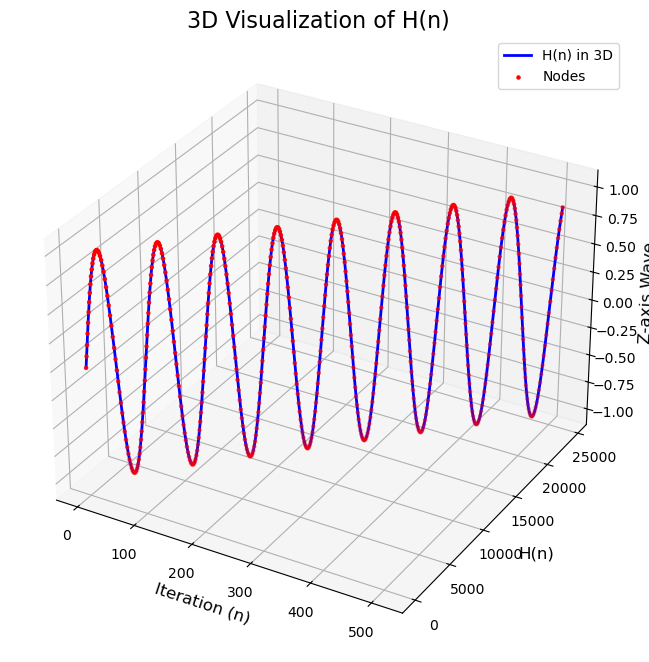

Original Text Data (First 100 characters): 
011010000110010101101100011011000110111110000000000000000000000000000000000000000000000000000000000
Decoded Text Data (First 100 characters): 
011010000110010101101100011011000110111110000000000000000000000000000000000000000000000000000000000
Data matches: True


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Input text data
text_data = """
01101000011001010110110001101100011011111000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000101000
"""  # Replace this with your text input

# Convert text to numerical representation
binary_data = np.frombuffer(text_data.encode('utf-8'), dtype=np.uint8)  # Encode text as bytes

# Step 1: Encode the Text Data into H (Storage)
def store_in_H(binary_data):
    # cumsum with int32
    cumsum_arr = np.cumsum(binary_data.astype(np.int32))
    return cumsum_arr

def retrieve_from_H(cumsum_arr):
    # difference in int32
    first_val = cumsum_arr[0]
    diffs = np.diff(cumsum_arr)
    diffs = np.insert(diffs, 0, first_val)
    return diffs.astype(np.uint8)

# Run the process
harmonics = store_in_H(binary_data)
retrieved_data = retrieve_from_H(harmonics)

# Visualize H(n)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Generate 3D coordinates
x = np.arange(len(harmonics))
y = harmonics
z = np.sin(x / 10.0)  # Arbitrary wave to add depth

# Plot the 3D visualization
ax.plot(x, y, z, label="H(n) in 3D", color='b', lw=2)
ax.scatter(x, y, z, color='r', s=5, label="Nodes")

# Labels and title
ax.set_title("3D Visualization of H(n)", fontsize=16)
ax.set_xlabel("Iteration (n)", fontsize=12)
ax.set_ylabel("H(n)", fontsize=12)
ax.set_zlabel("Z-axis Wave", fontsize=12)
ax.legend()
plt.show()

# Outputs: Original and Decoded Data Comparison
print("Original Text Data (First 100 characters):", text_data[:100])
print("Decoded Text Data (First 100 characters):", retrieved_data.tobytes().decode('utf-8', errors='replace')[:100])

# Validate the process
is_equal = text_data.encode('utf-8') == retrieved_data.tobytes()
print("Data matches:", is_equal)
if not is_equal:
    print("Differences detected in data.")
